In [1]:
# Arrange and save Matplotlib figures.
import matplotlib.pyplot as plt
# Work with numeric arrays and cell masks.
import numpy as np
# Summarize cells and results in tables.
import pandas as pd

# Open count stores and run Scarf analyses.
import scarf

# Keep routine logs and progress bars out of the results.
scarf.configure_output(level="WARNING", progress=False)

# Download the raw 10x count file for quality control.
counts = scarf.cytebase.connect("scarf_docs").download(
    "tenx_5K_pbmc_rnaseq/data.h5",
    destination="scarf_datasets",
)[0]

# Choose a separate store for this quality-control example.
store = counts.with_name("quality_control.zarr")
# Open a reader for the selected source format.
reader = scarf.CrH5Reader(str(counts))
# Write the converted count store.
scarf.CrToZarr(reader, zarr_loc=str(store)).dump()

# Open the count store for this analysis.
ds = scarf.DataStore(str(store), nthreads=4, min_features_per_cell=10)
# Inspect the opened store's cells and features.
ds

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

DataStore has 5025 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

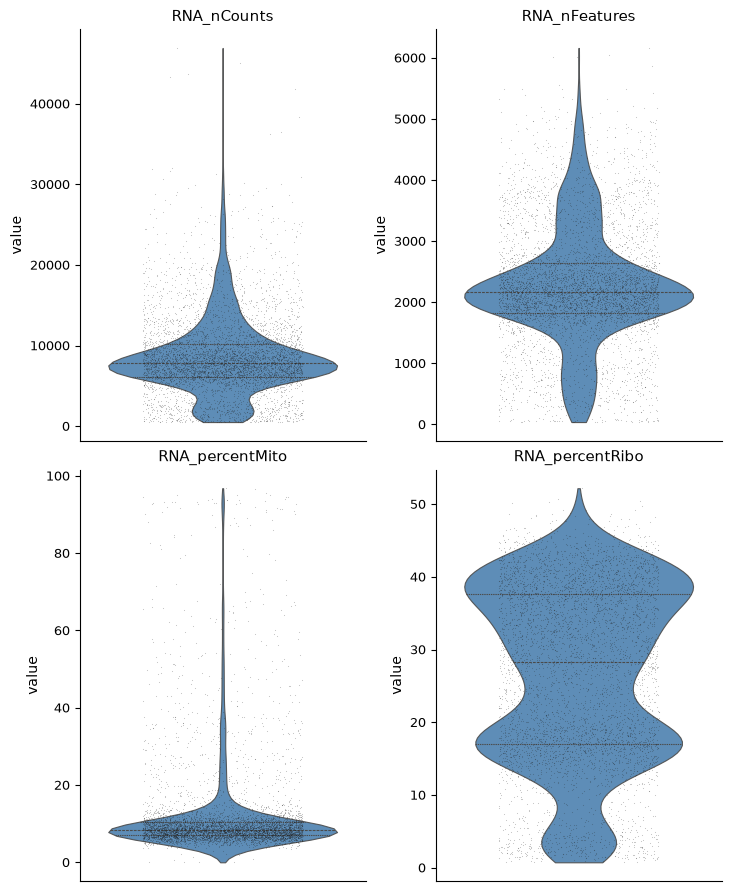

In [2]:
# Keep the quality measurements available in this store.
qc_cols = [
    c
    for c in ("RNA_nCounts", "RNA_nFeatures", "RNA_percentMito", "RNA_percentRibo")
    if c in ds.cells.columns
]
# Freeze the input cells before comparing filters.
qc_cell_selection = ds.snapshot_cell_selection("I")
# Inspect the input distributions of the available quality measurements.
ds.plots.distribution(keys=qc_cols, cell_selection=qc_cell_selection)

Cells after automatic filtering: 4331


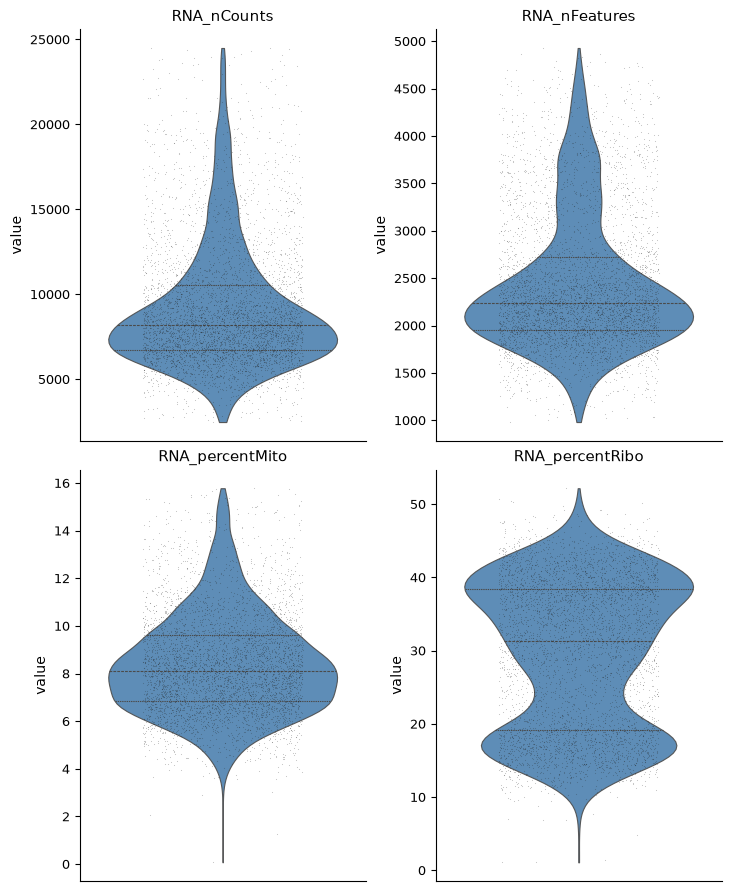

In [3]:
# Filter cells with the default robust thresholds.
automatic_selection = ds.auto_filter_cells(cell_selection=qc_cell_selection)
# Load the cells retained by automatic filtering.
automatic_mask = np.asarray(ds.load_artifact(automatic_selection)["values"][:], dtype=bool)
# Count cells retained by automatic filtering.
print(f"Cells after automatic filtering: {int(automatic_mask.sum())}")
# Inspect the same quality measurements after automatic filtering.
ds.plots.distribution(keys=qc_cols, cell_selection=automatic_selection)

In [4]:
# Count cells before applying manual thresholds.
n_before = int(ds.cells.fetch_all("I").sum())
# Define the manual count, feature, and mitochondrial thresholds.
manual_filter = {
    "attrs": ["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    "highs": [15000, 4000, 15],
    "lows": [1000, 500, 0],
}
# Apply the manual thresholds to the input cells.
manual_selection = ds.filter_cells(**manual_filter)
# Load the cells retained by manual filtering.
manual_mask = np.asarray(ds.load_artifact(manual_selection)["values"][:], dtype=bool)
# Report the input cell count.
print(f"Cells in input selection: {n_before}")
# Report the retained cell count.
print(f"Cells in filtered selection: {int(manual_mask.sum())}")
# Summarize the selected values and their spread.
pd.DataFrame({key: ds.cells.fetch_all(key)[manual_mask] for key in qc_cols}).describe()

Cells in input selection: 5025
Cells in filtered selection: 3948


,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo
count,3948.000000,3948.000000,3948.000000,3948.000000
mean,8241.683384,2269.690983,8.422534,30.185056
std,2472.030006,542.209124,2.121822,10.211426
min,1057.000000,512.000000,0.076336,0.737101
25%,6561.750000,1922.000000,6.892547,20.077556
50%,7881.000000,2185.500000,8.195208,32.447885
75%,9605.000000,2527.000000,9.721759,38.763019
max,14992.000000,3930.000000,14.975450,52.181596


In [5]:
# Read the RNA feature names.
feature_names = ds.RNA.feats.fetch_all("names").astype(str)
# Select genes whose names start with HSP.
stress_features = ds.set_feature_selection(
    from_assay="RNA",
    mask=np.char.startswith(feature_names, "HSP"),
)
# Calculate the selected genes' count percentage in each retained cell.
stress_percentage = ds.run_feature_percentage(manual_selection, stress_features)
# Load the calculated percentages.
stress_values = np.asarray(ds.load_artifact(stress_percentage)["values"][:])
# Summarize the selected values and their spread.
pd.Series(stress_values, name="percent stress features").describe()

count    3948.000000
mean        0.328236
std         0.130572
min         0.000000
25%         0.238440
50%         0.309681
75%         0.395623
max         1.531394
Name: percent stress features, dtype: float64

In [6]:
# Run the graph and clustering steps needed for doublet scoring.
doublet_run = ds.pipeline.run(
    filtering={"method": "manual", **manual_filter},
    hvg_count=500,
    pca_dims=15,
    leiden={"partitions": [0.5]},
    cell_cycle=False,
    paris=False,
    doublets=True,
    markers=False,
)
# Keep the doublet-score artifact for further filtering.
doublets = doublet_run["doublets"]
# Read the doublet scores in the analysis cell order.
scores = np.asarray(doublet_run.cells.fetch("doublet_score"))
# Name the scores for summaries and plots.
scores_series = pd.Series(scores, name="doublet_score")
# Summarize the selected values and their spread.
scores_series.describe()

count    3948.000000
mean        0.103634
std         0.118792
min         0.000000
25%         0.019126
50%         0.060054
75%         0.152437
max         1.000000
Name: doublet_score, dtype: float64

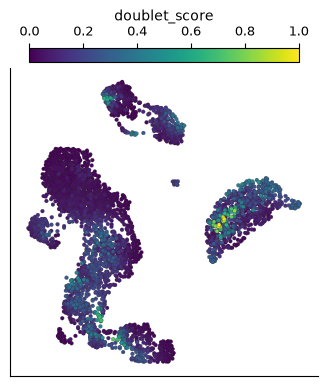

In [7]:
# Locate cells with high doublet scores on the UMAP.
ds.plots.embedding(run=doublet_run, color_by="doublet_score", sort_values=True)

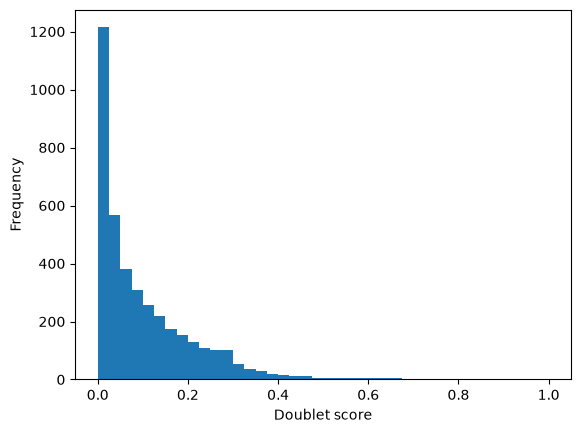

In [8]:
# Plot the doublet-score distribution.
scores_series.plot(kind="hist", bins=40, xlabel="Doublet score")
# Display the completed figure.
plt.show()

In [9]:
# Use the 95th percentile as this example's upper cutoff.
doublet_threshold = float(scores_series.quantile(0.95))
# Report the selected doublet-score cutoff.
print(f"Doublet threshold (95th percentile): {doublet_threshold:.4f}")
# Count cells excluded by the cutoff.
print(f"Cells above threshold: {int((scores > doublet_threshold).sum())}")

Doublet threshold (95th percentile): 0.3148
Cells above threshold: 198


In [10]:
# Retain cells whose score is at or below the chosen cutoff.
doublet_filtered = ds.select_cells(doublets, high=doublet_threshold, keep_bounds=True)
# Count the cells retained after applying the cutoff.
int(np.asarray(ds.load_artifact(doublet_filtered)["values"][:]).sum())

3750